# Carver engine + cross-sectional momentum
### a simple, faithful integration of Strategy 19

This rebuilds the single-asset Carver forecast engine and adds **one new layer**:
cross-sectional momentum (Robert Carver, *Advanced Futures Trading Strategies*, **Strategy 19**).

**What changed vs the single-asset tutorial**

- The four time-series forecasts (EWMAC, Breakout, Acceleration, Skew) and every
  sizing / backtest / metric function are **reused unchanged**.
- One new **multi-asset data layer** (`load_universe`). Cross-sectional momentum is
  *definitionally* multi-asset: it measures an instrument's move **relative to its
  peers**, so it cannot exist on a single series. With one asset the relative price
  is identically zero and the forecast is vacuous.
- One new forecast, `cs_momentum_forecast`, built the Carver way: normalised price
  (Strat 17) $\rightarrow$ asset-class normalised price (Strat 18) $\rightarrow$
  relative price $R$ (Strat 19) $\rightarrow$ horizon outperformance $\rightarrow$ scale, cap.
- The cross-rule **FDM is now derived from the forecast correlation matrix**
  ($\text{FDM}=1/\sqrt{w^\top C\,w}$) instead of the tutorial's cosmetic renormaliser of a sub-1 weight sum.

**Two honest caveats.**

1. The engine is **long-only** $[0,1]$, so the short leg of cross-sectional momentum
   (short the class underperformers) is floored at zero. You keep roughly half the rule.
2. Carver finds CS momentum is a **weak standalone** strategy (SR $\approx 0.34$,
   average drawdown $\approx -40\%$). Its value is **low correlation to trend**, not
   standalone return. The demo below reproduces exactly that.

> Data defaults to a crypto universe via `yfinance`, with a reproducible synthetic
> multi-asset fallback (shared market factor + rotating idiosyncratic leadership) so
> the notebook always runs. Numbers shown here are on the synthetic fallback; install
> `yfinance` for real crypto.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----- global Carver constants (unchanged from the single-asset build) -----
ANN_DAYS   = 365      # crypto trades 7 days/wk (use 252 for equities)
FC_TARGET  = 10.0     # forecast of 10 -> full vol-target position
FC_CAP     = 20.0     # forecasts clipped to +/- 2x the target
COST_BPS   = 3.25     # per-trade cost, bps
VOL_TARGET = 0.20     # portfolio vol target used in sizing

EWMAC_PAIRS = [(8, 32, 5.95), (16, 64, 4.10), (32, 128, 2.79), (64, 256, 1.91)]
EWMAC_FDM   = 1.13

In [2]:
# ============ core engine: vol stack, sizing, backtest, metrics (reused verbatim) ============
def ewm_std(x, span):
    """Carver bias-corrected EWM std."""
    a = 2.0 / (span + 1.0)
    m  = x.ewm(alpha=a, adjust=False).mean()
    m2 = (x * x).ewm(alpha=a, adjust=False).mean()
    var = (m2 - m * m).clip(lower=0.0)
    bc = (2.0 - 2.0 * a) / (2.0 - a)
    return np.sqrt(var / bc)

def vol_stack(close, ann_days=ANN_DAYS, short_span=30, anchor_years=5,
              anchor_min_years=1, short_w=0.70, long_w=0.30):
    """ret, vol_short, vol_long, blended vol (annualised), and sigma_p (EWMAC denominator)."""
    ann = np.sqrt(ann_days)
    ret = close.pct_change().clip(-0.9, 9.0)
    vol_short = ewm_std(ret, short_span) * ann
    vol_long  = vol_short.rolling(anchor_years * ann_days,
                                  min_periods=anchor_min_years * ann_days).mean()
    vol = pd.Series(np.where(vol_long.isna(), vol_short, short_w * vol_short + long_w * vol_long),
                    index=close.index, name="vol")
    sigma_p = (close * vol / ann).rename("sigma_p")
    return pd.DataFrame({"ret": ret, "vol_short": vol_short, "vol_long": vol_long,
                         "vol": vol, "sigma_p": sigma_p})

def clip_fc(f, cap=FC_CAP):
    return f.clip(-cap, cap)

def position_from_forecast(forecast, vol, vol_target=VOL_TARGET, fc_target=FC_TARGET, long_only=True):
    """weight = (forecast/10) * (vol_target/vol), clipped [0,1] long-only."""
    w = (forecast / fc_target) * (vol_target / vol)
    w = w.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return w.clip(0.0 if long_only else -1.0, 1.0).rename("weight")

def backtest(close, weight, cost_bps=COST_BPS, exec_lag=1):
    """held = weight.shift(1): decide at the close, act next bar (no look-ahead)."""
    ret = close.pct_change().fillna(0.0)
    held = weight.shift(exec_lag).fillna(0.0)
    turnover = held.diff().abs().fillna(held.abs())
    net = held * ret - turnover * (cost_bps / 1e4)
    return pd.DataFrame({"ret": ret, "weight": weight, "held": held,
                         "net": net, "equity": (1.0 + net).cumprod()})

def sharpe(net, ann_days=ANN_DAYS, rf=0.0):
    ex = net - rf / ann_days; sd = ex.std(ddof=1)
    return float("nan") if not sd else float(ex.mean() / sd * np.sqrt(ann_days))
def cagr(eq):
    eq = eq.dropna()
    if len(eq) < 2 or eq.iloc[-1] <= 0: return float("nan")
    yrs = (eq.index[-1] - eq.index[0]).days / 365.25
    return float(eq.iloc[-1] ** (1 / yrs) - 1) if yrs > 0 else float("nan")
def max_dd(eq):
    eq = eq.dropna(); return float((eq / eq.cummax() - 1).min()) if len(eq) else float("nan")
def ann_turnover(held, ann_days=ANN_DAYS):
    yrs = len(held) / ann_days; return float(held.diff().abs().sum() / yrs) if yrs > 0 else float("nan")
def report(name, res):
    print(f"{name:26s} Sharpe {sharpe(res['net']):5.2f}   CAGR {cagr(res['equity'])*100:6.1f}%"
          f"   MaxDD {max_dd(res['equity'])*100:6.1f}%   Turn {ann_turnover(res['held']):5.1f}x")

In [3]:
# ============ the four time-series forecasts + vol attenuation (reused verbatim) ============
def ewmac_forecast(close, sigma_p, pairs=EWMAC_PAIRS, fdm=EWMAC_FDM, cap=FC_CAP):
    subs = []
    for f, s, sc in pairs:
        raw = (close.ewm(span=f, adjust=False).mean() - close.ewm(span=s, adjust=False).mean()) / sigma_p
        subs.append((raw * sc).clip(-cap, cap))
    return (sum(subs) / len(subs) * fdm).clip(-cap, cap)

def breakout_single(close, n, sc, sm, cap=FC_CAP):
    mn, mx = close.rolling(n).min(), close.rolling(n).max(); rng = mx - mn
    spir = ((close - mn) / rng).where(rng > 0, 0.5)
    return ((spir - 0.5) * 40.0).ewm(span=sm, adjust=False).mean().mul(sc).clip(-cap, cap)
def breakout_forecast(close, fdm=1.17, cap=FC_CAP):
    P = [(40, 0.70, 10), (80, 0.73, 20), (160, 0.74, 40), (320, 0.74, 80)]
    subs = [breakout_single(close, n, sc, sm) for n, sc, sm in P]
    return (sum(subs) / len(subs) * fdm).clip(-cap, cap)

def ewmac_base(close, sigma_p, f, s, sc, cap=FC_CAP):
    return ((close.ewm(span=f, adjust=False).mean()
             - close.ewm(span=s, adjust=False).mean()) / sigma_p * sc).clip(-cap, cap)
def accel_forecast(close, sigma_p, fdm=1.55, cap=FC_CAP):
    bases = [ewmac_base(close, sigma_p, f, s, sc) for f, s, sc in EWMAC_PAIRS]
    AP, SC = [8, 16, 32, 64], [1.87, 1.90, 1.98, 2.05]
    subs = [((bases[i] - bases[i].shift(AP[i])) * SC[i]).clip(-cap, cap) for i in range(4)]
    return (sum(subs) / len(subs) * fdm).clip(-cap, cap)

def skew_forecast(ret, fdm=1.18, cap=FC_CAP):
    P = [(60, 33.3, 15), (120, 37.2, 30), (240, 39.2, 60)]
    subs = []
    for w, sc, sm in P:
        g = ret.rolling(w, min_periods=w // 2).skew()
        subs.append((-g).ewm(span=sm, adjust=False).mean().mul(sc).clip(-cap, cap))
    return (sum(subs) / len(subs) * fdm).clip(-cap, cap)

def vol_attenuation(vol, window=1260, smooth=10):
    p = vol.rolling(window, min_periods=252).rank(pct=True)
    p = p.ewm(span=smooth, adjust=False).mean()
    return (1.5 - p).clip(0.5, 1.5).fillna(1.0).rename("vol_att")

## New data layer — a peer universe

Cross-sectional momentum needs a **cross-section**. `load_universe` returns a
DataFrame of daily closes (one column per instrument), aligned on a common index.
It tries a crypto basket via `yfinance` and falls back to a synthetic universe with
a **shared market factor** (so the names co-move and each still trends) plus
**slowly-rotating idiosyncratic leadership** (so there is real relative dispersion
to demean). The instrument we actually trade is the first column (`BTC`).

In [4]:
def _synthetic_universe(names, n=2600, seed=11, s0=100.0):
    """Shared 3-state market factor + per-asset beta + slow-rotating idiosyncratic drift."""
    rng = np.random.default_rng(seed)
    P = np.array([[0.97, 0.01, 0.02], [0.02, 0.96, 0.02], [0.02, 0.02, 0.96]])
    mu = np.array([0.0012, -0.0014, 0.0002]); bvol = np.array([0.030, 0.045, 0.025])
    st, hm, mkt = 0, 0.0, []
    for _ in range(n):
        st = rng.choice(3, p=P[st]); hm = 0.94 * hm + 0.06 * rng.normal()
        mkt.append(mu[st] + bvol[st] * np.exp(0.5 * hm) * rng.normal())
    mkt = np.array(mkt)
    idx = pd.date_range(end=pd.Timestamp.today().normalize(), periods=n, freq="D")
    cols = {}
    for name in names:
        b  = rng.uniform(0.6, 1.4)      # beta to the market factor
        iv = rng.uniform(0.015, 0.035)  # idiosyncratic vol
        Pi = np.array([[0.995, 0.005], [0.005, 0.995]]); idr = np.array([0.0009, -0.0009])
        si, hi, r = rng.integers(0, 2), 0.0, np.empty(n)
        for t in range(n):
            si = rng.choice(2, p=Pi[si]); hi = 0.90 * hi + 0.10 * rng.normal()
            r[t] = b * mkt[t] + idr[si] + iv * np.exp(0.5 * hi) * rng.normal()
        cols[name] = s0 * np.exp(np.cumsum(r))
    return pd.DataFrame(cols, index=idx)

def load_universe(source="auto",
                  symbols=("BTC-USD","ETH-USD","BNB-USD","XRP-USD","SOL-USD","ADA-USD","DOGE-USD","LTC-USD"),
                  start="2018-01-01", seed=11):
    """Daily close panel. 'auto' tries yfinance, else a synthetic multi-asset series."""
    names = [s.split("-")[0] for s in symbols]
    if source in ("auto", "yfinance"):
        try:
            import yfinance as yf
            df = yf.download(list(symbols), start=start, auto_adjust=True, progress=False)["Close"]
            df.columns = [c.split("-")[0] for c in df.columns]
            df = df.dropna(how="all").ffill().dropna()
            if len(df) > 200 and df.shape[1] >= 3:
                return df
            raise RuntimeError("insufficient overlap")
        except Exception as e:
            if source == "yfinance": raise
            print(f"[load_universe] yfinance unavailable ({e!r}) -> synthetic universe.")
    return _synthetic_universe(names, seed=seed)

panel  = load_universe()
target = "BTC"
close  = panel[target]
vs     = vol_stack(close)
print(f"panel: {panel.shape[0]} bars x {panel.shape[1]} assets  {list(panel.columns)}")
print(f"span:  {panel.index[0].date()} -> {panel.index[-1].date()}   trading target = {target}")

[load_universe] yfinance unavailable (ModuleNotFoundError("No module named 'yfinance'")) -> synthetic universe.


panel: 2600 bars x 8 assets  ['BTC', 'ETH', 'BNB', 'XRP', 'SOL', 'ADA', 'DOGE', 'LTC']
span:  2019-05-26 -> 2026-07-07   trading target = BTC


## New layer — Cross-sectional momentum (Carver Strategy 19)

**Normalised price** (Strat 17). Volatility-normalise the *price path*, not just the
crossover. Reusing the Layer-0 risk-normalised return $r^{\text{norm}}=\text{ret}/(\text{vol}/\sqrt{\text{annDays}})$,

$$P^N = 100 \cdot \sum r^{\text{norm}},$$

a scale-free cumulative price with (near) constant vol through time.

**Asset-class normalised price** (Strat 18). Equal-weight average across the universe,
$A = \tfrac{1}{J}\sum_i P^N_i$.

**Relative price** (Strat 19). $R = P^N_{\text{target}} - A$. The subtraction is legal
because both are in the same vol-normalised units. $R$ rising $\Rightarrow$ the
instrument is outperforming its peers.

**Forecast.** Average daily outperformance over a horizon $H$, EWMA-smoothed at span
$H/4$, scaled so $\text{mean}|f|\approx 10$, capped $\pm 20$:

$$\text{raw}_H=\frac{R_t-R_{t-H}}{H},\qquad f_H=\text{scalar}_H\cdot \text{EWMA}_{H/4}(\text{raw}_H).$$

Two horizons (40, 80) kept deliberately low-DOF; combined with a small within-family
FDM. **The scalar is a calibration constant** — computed in-sample here for a
self-contained demo (printed as a check, exactly like every other layer). In
production you fix it once from a broad panel out-of-sample.

Because the engine is long-only, the bipolar $f$ simply floors at zero when BTC is
*under*performing the field — the short-leg caveat from the header, made concrete.

CS calibration: horizons=(40, 80)  scalars=[1.1, 1.6]  mean|cs| = 8.6  (target ~10)
corr(CS, EWMAC) = 0.25   corr(CS, Skew) = 0.08   <- CS is the low-correlation diversifier


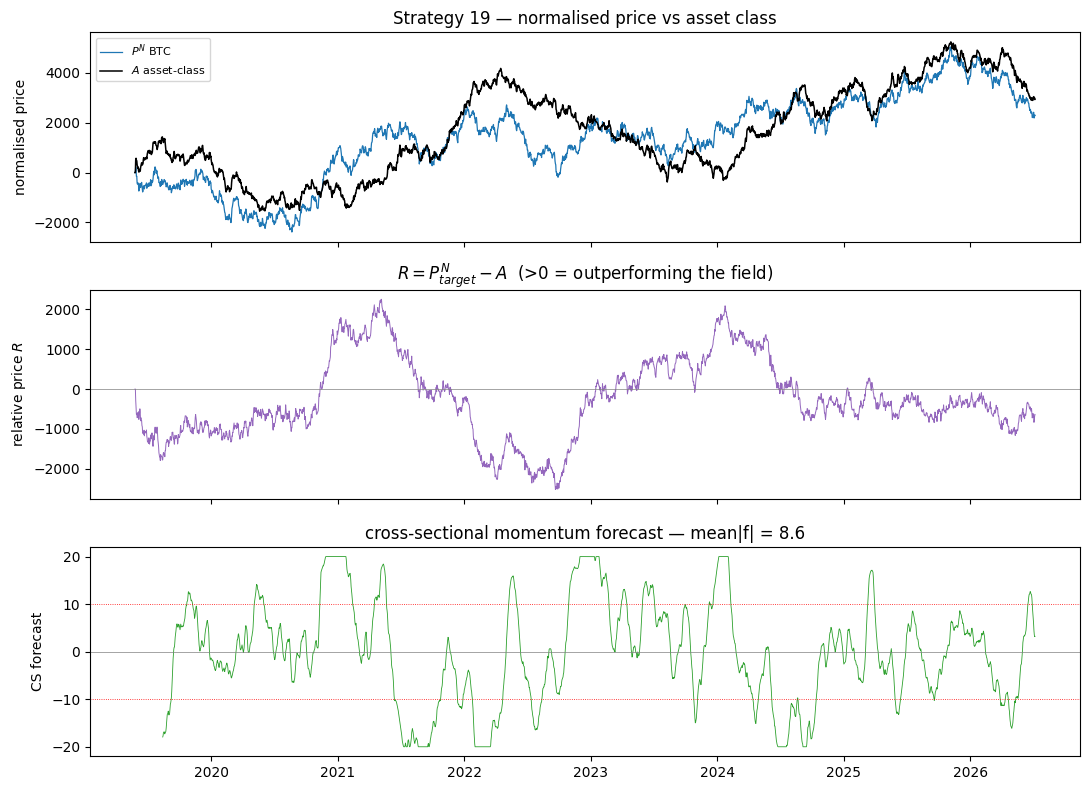

In [5]:
def normalised_price(close):
    """Carver Strat 17: 100 * cumsum(risk-normalised return). Reuses the Layer-0 vol stack."""
    v = vol_stack(close); ann = np.sqrt(ANN_DAYS)
    rn = (v["ret"] / (v["vol"] / ann)).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return (100.0 * rn.cumsum()).rename("PN")

def cs_momentum_forecast(panel, target="BTC", horizons=(40, 80), fam_fdm=1.10, cap=FC_CAP, verbose=False):
    PN = pd.DataFrame({c: normalised_price(panel[c]) for c in panel.columns})  # Strat 17, per asset
    A  = PN.mean(axis=1)                                                       # Strat 18, equal weight
    R  = PN[target] - A                                                        # Strat 19, relative price
    subs, scs = [], []
    for H in horizons:
        raw = (R - R.shift(H)) / H                                            # avg daily outperformance
        sm  = raw.ewm(span=max(2, H // 4), adjust=False).mean()
        sc  = 10.0 / sm.abs().mean() if sm.abs().mean() > 0 else 1.0          # scalar -> mean|f|~10
        scs.append(sc); subs.append((sm * sc).clip(-cap, cap))
    cs = (sum(subs) / len(subs) * fam_fdm).clip(-cap, cap)
    if verbose:
        print(f"CS calibration: horizons={horizons}  scalars={[round(float(s),1) for s in scs]}  "
              f"mean|cs| = {cs.abs().mean():.1f}  (target ~10)")
    return cs.reindex(panel.index).rename("CSmom")

# build all five forecasts for the target
ew = ewmac_forecast(close, vs.sigma_p)
br = breakout_forecast(close)
ac = accel_forecast(close, vs.sigma_p)
sk = skew_forecast(vs.ret)
cs = cs_momentum_forecast(panel, target, verbose=True)
print(f"corr(CS, EWMAC) = {ew.corr(cs):.2f}   corr(CS, Skew) = {sk.corr(cs):.2f}   "
      f"<- CS is the low-correlation diversifier")

# visualise the construction
PN = pd.DataFrame({c: normalised_price(panel[c]) for c in panel.columns})
A  = PN.mean(axis=1); R = PN[target] - A
fig, ax = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
ax[0].plot(PN.index, PN[target], color="tab:blue", lw=0.9, label=f"$P^N$ {target}")
ax[0].plot(A.index, A, color="k", lw=1.1, label="$A$ asset-class")
ax[0].legend(fontsize=8); ax[0].set_ylabel("normalised price"); ax[0].set_title("Strategy 19 — normalised price vs asset class")
ax[1].plot(R.index, R, color="tab:purple", lw=0.7); ax[1].axhline(0, color="gray", lw=0.5)
ax[1].set_ylabel("relative price $R$"); ax[1].set_title("$R = P^N_{target} - A$  (>0 = outperforming the field)")
ax[2].plot(cs.index, cs, color="tab:green", lw=0.6); ax[2].axhline(0, color="gray", lw=0.5)
for y in (-10, 10): ax[2].axhline(y, color="red", ls=":", lw=0.6)
ax[2].set_ylabel("CS forecast"); ax[2].set_title(f"cross-sectional momentum forecast — mean|f| = {cs.abs().mean():.1f}")
plt.tight_layout(); plt.show()

## Principled combine — FDM from the correlation matrix

The single-asset tutorial flagged its own weak spot: forecast weights summed to
0.65, and $0.65\times1.55\approx1.01$, so the "FDM" was really just renormalising a
sub-1 weight sum rather than paying for diversification. Here we do it properly.
Weights are normalised to sum to 1, and the forecast diversification multiplier is
computed from the empirical forecast correlation matrix,

$$\text{FDM}=\min\!\Big(2.5,\ \frac{1}{\sqrt{w^\top C\,w}}\Big).$$

Adding a genuinely low-correlation rule (CS) therefore *raises* the FDM — the extra
diversification is now quantified, not assumed.

In [6]:
def fdm_from_corr(w, C, fdm_max=2.5):
    w = np.asarray(w, float); w = w / w.sum()
    var = float(w @ C @ w)
    return float(min(fdm_max, 1.0 / np.sqrt(var))) if var > 0 else 1.0

def combine_forecasts(forecasts, weights, cap=FC_CAP):
    """forecasts/weights are dicts keyed by rule name. FDM derived from the corr matrix."""
    names = list(forecasts.keys())
    F = pd.concat([forecasts[n].rename(n) for n in names], axis=1)
    w = np.array([weights[n] for n in names], float); w = w / w.sum()
    C = F.dropna().corr().reindex(index=names, columns=names).values
    C = np.nan_to_num(C, nan=0.0); np.fill_diagonal(C, 1.0)
    fdm = fdm_from_corr(w, C)
    combined = (F.mul(w, axis=1).sum(axis=1) * fdm).clip(-cap, cap)
    return combined, fdm, F.dropna().corr()

five = {"EWMAC": ew, "Breakout": br, "Accel": ac, "Skew": sk, "CSmom": cs}
print("5-way forecast correlation (active periods):")
print(pd.concat(five.values(), axis=1, keys=five.keys()).dropna().corr().round(2).to_string())

5-way forecast correlation (active periods):
          EWMAC  Breakout  Accel  Skew  CSmom
EWMAC      1.00      0.96   0.66  0.00   0.25
Breakout   0.96      1.00   0.60  0.03   0.22
Accel      0.66      0.60   1.00  0.08   0.31
Skew       0.00      0.03   0.08  1.00   0.08
CSmom      0.25      0.22   0.31  0.08   1.00


In [7]:
def full_carver(panel, target="BTC", use_cs=True):
    """four TS forecasts (+ optional CS) -> corr-derived FDM -> vol attenuation -> long-only sizing."""
    close = panel[target].dropna(); vs = vol_stack(close)
    forecasts = {"EWMAC": ewmac_forecast(close, vs.sigma_p),
                 "Breakout": breakout_forecast(close),
                 "Accel": accel_forecast(close, vs.sigma_p),
                 "Skew": skew_forecast(vs.ret)}
    weights = {"EWMAC": 0.15, "Breakout": 0.15, "Accel": 0.15, "Skew": 0.20}
    if use_cs:
        forecasts["CSmom"] = cs_momentum_forecast(panel, target).reindex(close.index)
        weights["CSmom"] = 0.15                       # Carver gives CS momentum ~15% in his blend
    combined, fdm, corr = combine_forecasts(forecasts, weights)
    fc_att = clip_fc(combined * vol_attenuation(vs.vol))
    w = position_from_forecast(fc_att, vs.vol, long_only=True)
    return w, combined, fdm, corr

Isolated backtests (synthetic fallback):
Buy & hold                 Sharpe  0.20   CAGR  -13.2%   MaxDD  -76.5%   Turn   0.1x
EWMAC                      Sharpe -0.10   CAGR   -1.5%   MaxDD  -25.4%   Turn   2.3x
Skew                       Sharpe  0.35   CAGR    1.6%   MaxDD  -16.8%   Turn   0.6x
CSmom (long-only)          Sharpe -0.13   CAGR   -3.0%   MaxDD  -39.0%   Turn   2.7x
   ^ weak standalone + low correlation: exactly Carver's finding for CS momentum

Full engine A/B  (FDM now real, from the corr matrix):
   FDM without CS = 1.40      FDM with CS = 1.52   (+0.12: the diversification CS adds, quantified)
FULL engine (no CS)        Sharpe  0.17   CAGR    1.2%   MaxDD  -14.4%   Turn   2.9x
FULL engine (with CS)      Sharpe  0.19   CAGR    1.5%   MaxDD  -14.5%   Turn   3.0x


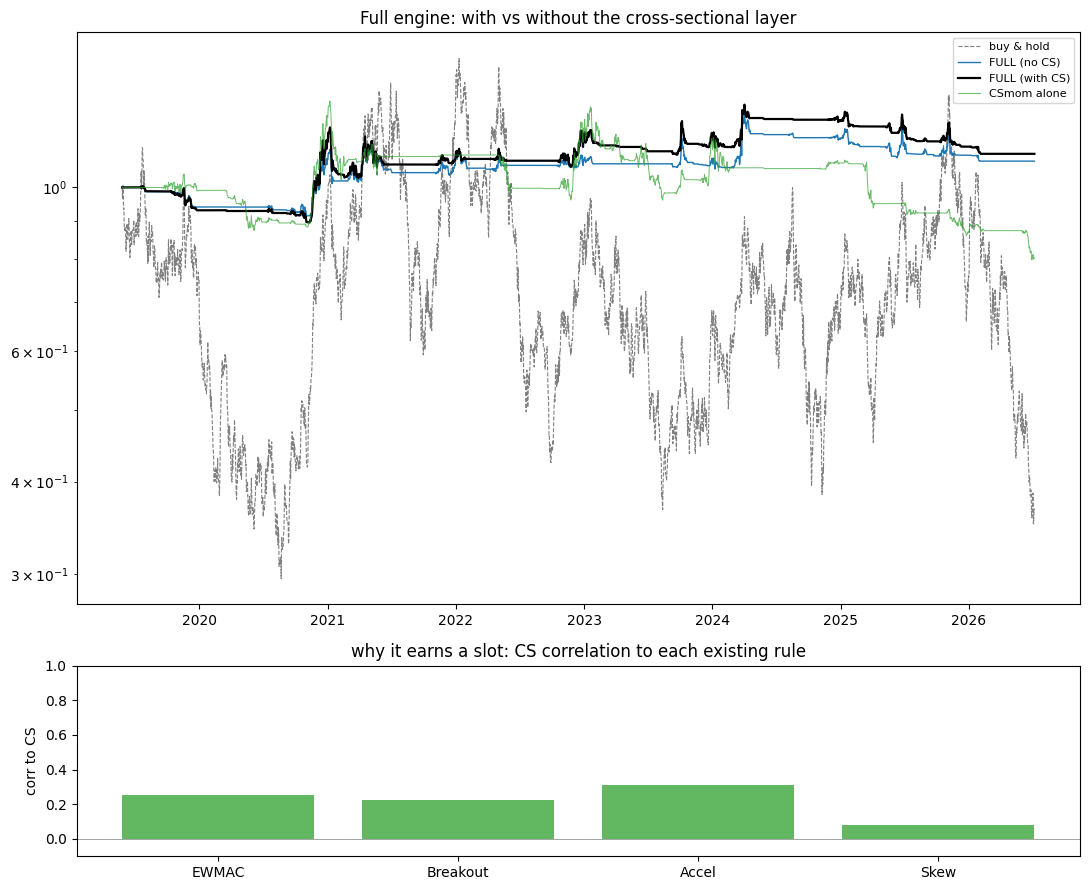

In [8]:
# ---- isolated behaviour + the A/B that isolates the marginal effect of CS ----
print("Isolated backtests (synthetic fallback):")
report("Buy & hold",         backtest(close, pd.Series(1.0, index=close.index)))
report("EWMAC",              backtest(close, position_from_forecast(ew, vs.vol)))
report("Skew",               backtest(close, position_from_forecast(sk, vs.vol)))
report("CSmom (long-only)",  backtest(close, position_from_forecast(cs, vs.vol)))
print("   ^ weak standalone + low correlation: exactly Carver's finding for CS momentum\n")

w_no,  comb_no,  fdm_no,  _ = full_carver(panel, target, use_cs=False)
w_yes, comb_yes, fdm_yes, _ = full_carver(panel, target, use_cs=True)
res_no, res_yes = backtest(close, w_no), backtest(close, w_yes)
print(f"Full engine A/B  (FDM now real, from the corr matrix):")
print(f"   FDM without CS = {fdm_no:.2f}      FDM with CS = {fdm_yes:.2f}   "
      f"(+{(fdm_yes-fdm_no):.2f}: the diversification CS adds, quantified)")
report("FULL engine (no CS)",   res_no)
report("FULL engine (with CS)", res_yes)

fig, ax = plt.subplots(2, 1, figsize=(11, 9), gridspec_kw={"height_ratios": [3, 1]})
bh = (close / close.iloc[0])
ax[0].plot(bh.index, bh, color="gray", lw=0.8, ls="--", label="buy & hold")
ax[0].plot(res_no.index,  res_no.equity,  color="tab:blue", lw=1.0, label="FULL (no CS)")
ax[0].plot(res_yes.index, res_yes.equity, color="k",        lw=1.6, label="FULL (with CS)")
ax[0].plot(backtest(close, position_from_forecast(cs, vs.vol)).equity, color="tab:green", lw=0.7, alpha=0.7, label="CSmom alone")
ax[0].set_yscale("log"); ax[0].legend(fontsize=8); ax[0].set_title("Full engine: with vs without the cross-sectional layer")
corrs = {k: cs.corr(v) for k, v in {"EWMAC": ew, "Breakout": br, "Accel": ac, "Skew": sk}.items()}
ax[1].bar(list(corrs.keys()), list(corrs.values()), color="tab:green", alpha=0.75)
ax[1].axhline(0, color="gray", lw=0.5); ax[1].set_ylim(-0.1, 1.0)
ax[1].set_ylabel("corr to CS"); ax[1].set_title("why it earns a slot: CS correlation to each existing rule")
plt.tight_layout(); plt.show()

## Where to take it next

- **Real universe.** `pip install yfinance` and the crypto basket loads automatically.
  For a survivorship-clean panel, include delisted names to their delisting rather
  than filtering to today's liquid set — the asset-class index $A$ inherits any
  survivorship bias in the panel. Contemporaneous demeaning itself is *not*
  look-ahead: $R_t$ uses only cross-sectional information at $t$, and the horizon
  window is trailing.
- **Refit the scalar out-of-sample.** The CS scalar is calibrated in-sample here for
  a self-contained demo. Fix it once from a broad panel, then hold it, like the other
  layers' hard-coded scalars.
- **The short leg.** In a long-only sleeve the CS forecast floors at zero when the
  target underperforms the field, so you keep roughly half the rule. To express the
  full rule you would size a market-neutral basket (Carver's Part Five methodology),
  which is a different sizing engine from this one.
- **Weights.** CS is set to 15% (Carver's own allocation) and the FDM is derived from
  the correlation matrix. A/B `use_cs=False` vs `True` to see the marginal effect on
  *your* data; expect diversification (higher FDM, steadier path) rather than a large
  standalone-return jump.